In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([2.0, 0.02])

# train_data = "../data/output_train.npz"
# valid_data = "../data/output_train.npz"

train_data = "../data/combined_output_new_train.npz"
valid_data = "../data/combined_output_new_test.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (2, 11, 11)
xb.shape      = (2, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (2, 11, 11)
xb.shape      = (2, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [3]:

final_model, train_history, valid_history = train_model(DiagonalPlusEnergyNN, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=5e-2, init_K=K_init)

Epoch 000 | Train: 1.571e-04 | Valid: 1.538e-04
Epoch 010 | Train: 1.033e-04 | Valid: 1.256e-04
Epoch 020 | Train: 8.626e-05 | Valid: 1.117e-04
Epoch 030 | Train: 8.323e-05 | Valid: 9.106e-05
Epoch 040 | Train: 8.272e-05 | Valid: 8.288e-05
Epoch 050 | Train: 8.207e-05 | Valid: 8.857e-05
Epoch 060 | Train: 8.196e-05 | Valid: 9.324e-05
Epoch 070 | Train: 8.192e-05 | Valid: 9.238e-05
Epoch 080 | Train: 8.189e-05 | Valid: 9.006e-05
Epoch 090 | Train: 8.189e-05 | Valid: 9.009e-05
Epoch 100 | Train: 8.188e-05 | Valid: 9.100e-05
Epoch 110 | Train: 8.188e-05 | Valid: 9.098e-05
Epoch 120 | Train: 8.188e-05 | Valid: 9.063e-05
Epoch 130 | Train: 8.188e-05 | Valid: 9.068e-05
Epoch 140 | Train: 8.188e-05 | Valid: 9.080e-05
Epoch 150 | Train: 8.188e-05 | Valid: 9.076e-05
Epoch 160 | Train: 8.188e-05 | Valid: 9.072e-05
Epoch 170 | Train: 8.188e-05 | Valid: 9.075e-05
Epoch 180 | Train: 8.188e-05 | Valid: 9.075e-05
Epoch 190 | Train: 8.188e-05 | Valid: 9.074e-05
Epoch 200 | Train: 8.188e-05 | Valid: 9.

500


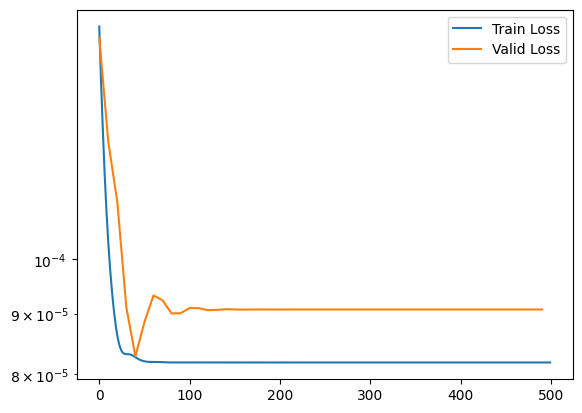

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
base, aux = get_slinky()
valid = Dataset.load(valid_file)
pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [6]:
animate(pred[0])

In [7]:
animate(valid.qs[0])

In [8]:
animate(pred[1])

In [9]:
animate(valid.qs[1])

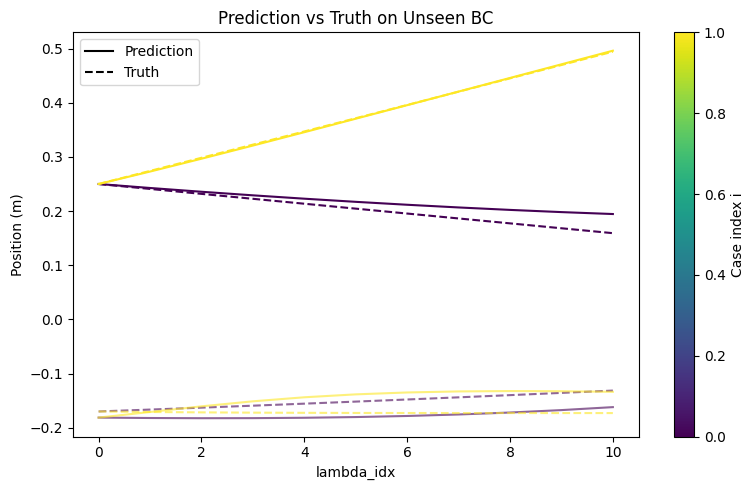

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()